# Antab file generation

Script implements the following:
- Loading a manually generated RXG file
- Generation of the antab file from the RXG file, scan info, telstate data, and power file.
- Also required is a beam gain per VLBI channel, that can change over time, which gets multipled with the power file prior to writing to the antab file.

Components of gain equation to be verified elsewhere and copied here in a modular way:
- translation of wideband to narrowband power (DEFERRED, just using the narrowband calibration solutions)
- translation to tied-array beam power, based on calibration solutions, and variation thereof over time.
- translation to VLBI output power. 

Rev A:
- Creating / reading the RXG file
- Creating all the antab file fields, though writing power values instead of Tsys

Rev B:
- Writing Tsys to the antab file rather than power values. 
- Keep things modular: create Tsys files in equivalent format to the power files, and just provide these to the existing antab writer.
- Create Tsys files in a distinct class, to be created here.

Rev C:
- Streamlining parameter sharing.
- Adding some diagnostic functions / plots.
- Fixed antab date string bug.
- Cleaning up and documenting code.
- Include any adjustments discovered during gain model verification [verified, no modifications].
- TBD: Option for conversion to circular pol.
- TBD: some way to extract and propagate the band frequencies, such that I needn't have to define it manually.
  
Rev D:
- Option for conversion to circular pol.
- TBD: some way to extract and propagate the band frequencies, such that I needn't have to define it manually. Will include key parameters in the CSV catalogue file.

Rev E:
- Updating the catalogue reader file to read observation info from its header.

Rev 1:
- clean up and documenting.

Rev 2:
- addressing bugs: (i) adding beamformer weights to Tsys calculation, (ii) cal timestamp selection.

Rev 3:
- updated catalogue parsing function for phase-up correction parameters in schedule file header.
- ignoring phase-up correction scans during processing.
- addressing case-sensitivity on calscan_prefix and validscans
- Selecting valid calibration solutions according to scan names, and updating selection of most appropriate calibrator scan timestamp to use during Tsys calibration. 


In [1]:
# Experiments

# EVN Session 1:
# n24l3, 1729171747
# n25l1, 1740055990
# em181a, 1740224791
# es116a, 1740943459

# EVN Session 2:
# n25l2: 1749383603
# em180a: 1749409153
# - significant difference between H and V pol flux levels; lower flux than expected.
# - apparent poor phase-up, given scatter of g solution phases (see cal report)
# - used J1939-6342, m063 as ref (though other obs did too), 48 antennas
# - preceding phase-up looks fine; only 30 min before obs.
# - something happened to disturb phases in between phase-up and obs, not clear what.
# ed051a: 1749724290
# em180b: 1749814757

# LBA test, 14-08-2025
# vt33a: 1755154278

# EVN Session 3 2025
# n25l3 comments: 
# - Note that there are distinct CSV catalogue files for 18 and 21cm. Rename each appropriately when doing analysis for that band.
# - Except for the cal scans, there's no need to rename the power output files since these are labelled per scan. Cal scans with the same
#   number from different observations will be overwritten, though that doesn't really matter. In future, use different cal scan numbers 
#   in the different observations.
# - the auxiliary files however require significant changes, as both observations need to be combined into one file.
# n25l3, 1761049693 (18cm).  
# n25l3, 1761056293 (21cm).
# el079b, 1761145885
# gg090, 1761508048


In [2]:
# Main parameters

# VLBI Experiment name (sets the catalogue file name)
exp_name = 'pcctest'
# NARROWBAND observation RDB file corresponding to the experiment
obs_cbid = "1769593762"
# RXG filename (generated manually, stored in cal directory)
fn_rxg = 'calmel.rxg'
# Station code
station_code = 'me'
# Valid scan prefix. Prefix of scans to be included in antab file.
validscan_prefix = 'scan no'
#validscan_prefix = None  # For debugging, includes all available / processed scans

# Observation catalogue directory
cat_dir = '/home/mgouws/vlbi/catalogues/'
# Location of VLBI channel power files (stored per scan)
pwr_dir = '/home/mgouws/vlbi/pwr_files/'
# Output directory for calibration files
cal_dir = '/home/mgouws/vlbi/metadata/'
# Location to download rdb files
rdb_dir = '/home/mgouws/vlbi/rdb_files/'


In [3]:
# Imports and definitions

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import os
import os.path
from datetime import datetime, timedelta, timezone

import katdal
import katpoint

from baseband import vdif
import astropy.units as u
from astropy.time import Time as ap_time
from astropy.time import TimeDelta as ap_tdelta


def parse_vlbi_cat(vlbi_cat_fn, proc_buffer_sec=1, ref_ant=None):
    """ Parses the provided VLBI catalogue file and provides a list of scan parameters and
    a katpoint catalogue of unique targets in the observation. 

    Parameters
    ----------
    vlbi_cat_fn : string
        Location of text file containing observation scan information
    proc_buffer_sec : integer 
        Buffer time in seconds added before and after processing start and 
        stop time. 
    ref_ant : katpoint Antenna object
        Reference antenna for katpoint Catalogue

    Returns
    -------
    obs_params : Dictionary
        Dictionary with observation parameters.
    scan_params : list of dictionaries
        List of dictionaries with paramters for each scan.
    vlbi_cat : katpoint Catalogue object
        katpoint catalogue with unique targets to be observed.
        
    """
    # Read the VLBI catalogue file 
    with open(vlbi_cat_fn, 'r') as cat_file:
        csv_lines = [line for line in cat_file.readlines()]
    # Read header info
    header_lines = [line[1:].strip() for line in csv_lines if line.startswith('#')]
    hdr_keys = ['EXPERIMENT', 'POL', 'CAL_PREFIX', 'PCC_PREFIX', 'PCC_VERIFICATION'] 
    obs_params = dict.fromkeys(hdr_keys)
    obs_params['CHANNELS'], hdr_ch_key = {}, 'CH'
    for line in header_lines:
        hdr_key, hdr_par = line.split(' ')[0], line.split(' ')[1:]
        if hdr_key in hdr_keys:
            obs_params[hdr_key] = ' '.join(hdr_par)
        elif line.startswith(hdr_ch_key):
            obs_params['CHANNELS'][hdr_key] = hdr_par
    # Create list of scan parameters
    scan_params = {}
    scan_lines = [line for line in csv_lines if not line.startswith('#')]
    for scan_line in scan_lines:
        # Scan name
        scan_name = scan_line.split(',')[-3].strip()
        # Datetime of scan start time
        start_time_str = scan_line.split(',')[-2].strip()
        start_time = datetime.strptime(start_time_str, '%Y-%m-%d %H:%M:%S.%f')
        start_time = start_time.replace(tzinfo=timezone.utc)
        # Start time for processing of scan
        start_time_proc = start_time - timedelta(seconds=proc_buffer_sec)  
        # Duration
        duration = int(scan_line.split(',')[-1])
        # Target name
        tgt_string = scan_line.split(',')[0].split('|')[0].strip()
        tgt_string = tgt_string[1:] if tgt_string.startswith('*') else tgt_string
        # Create a katpoint target line
        kp_target_ln = ', '.join([kp.strip(' ') for kp in scan_line.split(',')[:-3]]) 
        # Store scan parameters
        scan_params[scan_name] = {'target':tgt_string,
                                  'start_iso':scan_line.split(',')[-2],
                                  'start_ts':start_time.timestamp(),
                                  'duration':duration,
                                  'kp_tgt':katpoint.Target(kp_target_ln, antenna=ref_ant),
                                  'proc_start_iso':start_time_proc.strftime('%Y-%m-%dT%H:%M:%S.%f'),
                                  'proc_start_ts':start_time_proc.timestamp(),                               
                                  'proc_duration':duration+2*proc_buffer_sec}
    # Sort dictionary entries by scan start time
    sorted_params = sorted(scan_params.items(), key=lambda e:e[1]['start_ts'])
    scan_params = dict(sorted_params)
    # Create a katpoint catalogue for unique targets
    kp_target_list = []
    for scan_name, scan_pars in scan_params.items():
        if scan_pars['kp_tgt'] not in kp_target_list:
            kp_target_list.append(scan_pars['kp_tgt'])
    vlbi_cat = katpoint.Catalogue(kp_target_list, antenna=ref_ant)
    return obs_params, scan_params, vlbi_cat


def parse_chan_params(vex_params, chan_map):
    """ Parse channel parameters read from a VLBI observation catalogue 
    file and compute frequency parameters required for pipeline 
    post-processing. FIXME: This is only valid for a 2-channel band
    and needs to be updated to accommodate expanded channels.

    Parameters
    ----------
    vex_params : Dictionary
        Dictionary with VEX-file parameters as read from VLBI catalogue 
        header.
    chan_map : Dictionary 
        Dictionary mapping the antab-standard channel names to the 
        channel names used in pipeline-generated channel power files. 

    Returns
    -------
    fc_band : float
        Value of the VLBI band center frequency in Hz.
    bw_chan : float
        Value of the VLBI channel bandwidth in Hz.
    fc_chans : Dictionary
        Dictionary indexed by power-file channel names containing.
        the center frequency of each in Hz.
    antab_chan_def : Dictionary
        Dictionary indexed by antab-file channel names containing.
        parameters required within the antab file.
    
    """
    fc_chans, chan_def = {}, {}
    for vex_ch_desc in vex_params['CHANNELS'].values():
        fc_band_MHz, sb_chan, bw_chan_MHz, pol_chan = vex_ch_desc
        fc_band_MHz, bw_chan_MHz = float(fc_band_MHz), float(bw_chan_MHz)
        fc_chan_MHz = fc_band_MHz-bw_chan_MHz/2.0 if sb_chan=='LSB' else fc_band_MHz+bw_chan_MHz/2.0
        # Channel name as per Tsys file header
        tsys_pol_name = 'pol0' if pol_chan=='RCP' else 'pol1'
        tsys_ch_name = sb_chan.lower()+'-'+tsys_pol_name 
        # Channel center frequency in Hz 
        fc_chans[tsys_ch_name] = fc_chan_MHz*1e6
        # Antab info: channel_name:[fc_chan, sideband, bw_chan]
        chan_def[tsys_ch_name] = [fc_chan_MHz, sb_chan, bw_chan_MHz]
    # Remap antab chan definition with antab channel names
    antab_chan_def = {antab_ch:chan_def[chan_map[antab_ch]] for antab_ch in chan_map.keys()}
    return fc_band_MHz*1e6, bw_chan_MHz*1e6, fc_chans, antab_chan_def


class antab_writer():
    """ Class for antab file creation. """

    def __init__(self, station_name, path_rxg, chan_def, print_rxg=False):
        """ Initialise antab station parameters.
        
        Parameters
        ----------
        station_name : string
            Two-character VLBI station code.
        path_rxg : string 
            Path to rxg file.
        chan_def : Dictionary 
            Dictionary mapping the antab-standard channel names to the 
            channel names used in pipeline-generated channel power files. 
        print_rxg : Bool 
            Prints contents of rxg file if True.  
        
        """
        # Station name to be printed in antab file
        self.station_name = station_name.upper()
        # Read parameters from the supplied RXG file
        self.rxg_pars = self.read_rxg_parameters(path_rxg, print_rxg)
        # VLBI channel definition dictionary
        self.chan_def = chan_def
        # List of text lines to be printed to file
        self.file_lines = []

    def read_rxg_parameters(self, path_rxg, print_output):
        """ Return a dictionary containing standard parameters from the supplied RXG file.

        Parameters
        ----------
        path_rxg : string 
            Path to rxg file.
        print_output : Bool 
            Prints contents of rxg file if True.  
        
        """
        rxg_pars = {}
        with open(path_rxg, 'r') as rxg_file:
            # Read file and remove commented lines
            rxg_lines = rxg_file.readlines()
            rxg_lines = [line.strip() for line in rxg_lines if not line.startswith('*')]
            # 1st line: LO parameter
            rxg_pars['LO'] = rxg_lines[0]
            # 2nd line: Creation date
            rxg_pars['DATE'] = rxg_lines[1]
            # 3rd line: FWHM beamwidthm
            rxg_pars['FWHM'] = rxg_lines[2]
            # 4th line: Polarizations available
            rxg_pars['POLS'] = rxg_lines[3]
            # 5th line: DPFU (degrees/Jansky) for polarizations
            rxg_pars['DPFU'] = rxg_lines[4]
            # 6th line: Gain curve
            rxg_pars['GAIN'] = rxg_lines[5]
            # 7th and following lines: Tcal versus frequency table
            tcal_lines = []
            for ii_l in range(6, len(rxg_lines)):
                if rxg_lines[ii_l]=='end_tcal_table':
                    ii_trec = ii_l+1
                    break
                tcal_lines.append(rxg_lines[ii_l])
            rxg_pars['TCAL'] = tcal_lines
            # 8th parameter: Trec
            rxg_pars['TREC'] = rxg_lines[ii_trec]
            # 9th parameter: Spillover table
            spillover_lines = []
            for ii_l in range(ii_trec+1, len(rxg_lines)):
                if rxg_lines[ii_l]=='end_spillover_table':
                    break
                spillover_lines.append(rxg_lines[ii_l])
            rxg_pars['SPILL'] = spillover_lines
        if print_output:
            print("RXG parameters:")
            for key, par in rxg_pars.items():
                print("{}: {}".format(key, par))
        return rxg_pars

    def add_lines(self, lines):
        """ Append provided list of text lines to output file line list.

        Parameters
        ----------
        lines : list 
            List of line strings to be added to file.
        
        """
        for line in lines:
            self.file_lines.append(line)

    def header_lines(self, exp_name):
        """ Write standard header lines in the antab file.

        Parameters
        ----------
        exp_name : string 
            VLBI experiment name.
        
        """
        date_today = datetime.now().strftime("%Y-%m-%d")
        line = []
        line.append('! Amplitude calibration data for {} in {}.'.format(self.station_name, exp_name))
        line.append('! Produced on {}.'.format(date_today))
        return line

    def gain_lines(self):
        """ Generate text lines related to the gain model.
        """
        # Create gain line
        gain_line = 'GAIN {} ELEV DPFU='.format(self.station_name)
        # Add DFPU parameters
        gain_line += ','.join(self.rxg_pars['DPFU'].split())
        # Add FREQ parameters. 
        # - TBC: values seem to be (min channel fc) - bw, (max channel fc) + bw
        chan_fcs = [ch_data[0] for ch_data in self.chan_def.values()]
        chan_bw = [ch_data[-1] for ch_data in self.chan_def.values()][0]
        min_freq, max_freq = min(chan_fcs)-chan_bw, max(chan_fcs)+chan_bw
        gain_line += " FREQ={:.2f},{:.2f}".format(min_freq, max_freq)
        # Add POLY parameters
        gain_line += " POLY="
        gain_line += ','.join(self.rxg_pars['GAIN'].split()[2:])
        # Add slash
        gain_line += ' /'
        return [gain_line]

    def make_file(self, exp_name, tsys_fns, channel_map, tgt_scans):
        """ Create antab file, with formatting roughly consistent with output of 'antabfs.py' 
        (https://deki.mpifr-bonn.mpg.de/@api/deki/files/8814/=antabfs_ys.py).

        Parameters
        ----------
        exp_name : string
            VLBI experiment name.
        tsys_fns : string 
            Dictionary of CSV file names indexed by scan name, where each file 
            contains the Tsys values for a scan over time.
        channel_map : Dictionary 
            Dictionary mapping the antab-standard channel names to the 
            channel names used in pipeline-generated channel power files. 
        tgt_scans : Bool 
            Dictionary with the string name of the observed target, indexed by scan
            name.  
        
        """
        # Add header lines
        header_lines = self.header_lines(exp_name)
        self.add_lines(header_lines)
        # Add GAIN line
        gain_lines = self.gain_lines()
        self.add_lines(gain_lines)
        self.add_lines(['/'])
        # Add Tsys line
        self.add_lines(['TSYS {} FT = 1.0 TIMEOFF=0'.format(self.station_name)])
        # Add index line, ordering channels by R, L and by increasing frequency
        chans_ordered = sorted([ch for ch in self.chan_def.keys() if ch.startswith('R')])
        chans_ordered += sorted([ch for ch in self.chan_def.keys() if ch.startswith('L')])
        index_line = "INDEX= "
        index_line = ','.join(["'{}'".format(ch) for ch in chans_ordered])
        self.add_lines([index_line])
        self.add_lines(['/'])
        # Create commented section describing the columns
        for ii_ch, ch in enumerate(chans_ordered):
            ch_line = "!Column {} = {}: {} MHz, {}, BW={} MHz".format(ii_ch+1, ch, *self.chan_def[ch])
            self.add_lines([ch_line])
        # Add power entries per scan
        for scan_name, tsys_fn in tsys_fns.items():
            # Load CSV data with pandas
            df = pd.read_csv(tsys_fn)
            hdr_keys = df.keys().to_list()
            t_strlist = list(df['time'].array)
            t_axis = ap_time(t_strlist, format='isot')
            p_vals = {ch:df[channel_map[ch]].array for ch in chans_ordered}
            # Create scan info line
            t_val = t_axis[0].to_value('yday')
            yday, hh, mm, ss = t_val.split(':')[1:]
            sline = "! {} {}:{:05.2f}: ".format(yday, hh, int(mm)+float(ss)/60.0)
            scan_num = scan_name.split(' ')[-1]
            sline += "scanNum={} scanName={} source={}".format(scan_num[-4:], scan_num, tgt_scans[scan_name]) 
            self.add_lines([sline])
            # Print time / Tsys per band
            for ii_t in range(len(t_strlist)):
                # Convert to desired time format: "yday hh:mm" with float minutes.
                t_val = t_axis[ii_t].to_value('yday')
                yday, hh, mm, ss = t_val.split(':')[1:]
                pline = "{} {}:{:05.2f}".format(yday, hh, int(mm)+float(ss)/60.0)
                for ch in chans_ordered:
                    pline += " {:.1f}".format(p_vals[ch][ii_t])
                self.add_lines([pline])
        self.add_lines(['/'])

    def write_to_file(self, fn_antab):
        """ Write all text lines to the specified file. """
        with open(fn_antab, 'w') as antab_file:
            for line in self.file_lines:
                antab_file.write(line)
                antab_file.write('\n')

    def print_all(self):
        """ Print all text lines for inspection. """
        for line in self.file_lines:
            print(line)


class vlbi_station_cal:
    """ Calculation of beam calibration gains and creation of observation Tsys files. """

    def __init__(self, obs_cbid, exp_name, fc_chans, bw_chan,
                 rdb_dir, out_dir, gain_tab=0.5):
        """ Set observation parameters.
        
        Parameters
        ----------
        obs_cbid : string or int
            Narrowband capture block ID of the VLBI observation.
        exp_name : string 
            Name of the VLBI experiment.
        fc_chans : Dictionary
            Dictionary indexed by power-file channel names containing.
            the center frequency of each in Hz.
        bw_chan : float
            Value of the VLBI channel bandwidth in Hz.
        rdb_dir : string
            Directory where rdb files are saved.
        out_dir : string 
            Directory where output Tsys CSV files will be saved.
        gain_tab : float 
            Value of the tied-array gain during the observation (Default: 0.5).  
        
        """
        # Observation CBID
        self.obs_cbid = obs_cbid
        # RDB file location
        self.rdb_dir = rdb_dir
        # VLBI experiment name
        self.exp_name = exp_name
        # Dictionary mapping channel to center frequency 
        self.fc_chans = fc_chans
        # Bandwidth of VLBI channels
        self.bw_chan = bw_chan
        # Output directory for storing output Tsys files
        self.out_dir = out_dir
        # Tied-array beam gain setting
        self.gain_tab = gain_tab

    def valid_cal(self, cs_name, cal_kws=['mcal', 'verify']):
        """ Return True if the supplies compscan name contains calibration scan keywords. """
        if np.any([cal_cs in cs_name for cal_cs in cal_kws]):
            return True
        return False

    def clean_bandpass(self, bp_gains, cal_channel_freqs, max_gap_Hz):
        """Clean up bandpass gains by linear interpolation across narrow flagged regions.
        Shamelessly copied from https://github.com/ska-sa/katsdpscripts/blob/master/observation/bf_phaseup.py
        """
        clean_gains = {}
        # Linearly interpolate across flagged regions as long as they are not too large
        for inp, bp in bp_gains.items():
            flagged = np.isnan(bp)
            if flagged.all():
                clean_gains[inp] = np.zeros_like(bp)
                continue
            chans = np.arange(len(bp))
            interp_bp = np.interp(chans, chans[~flagged], bp[~flagged])
            # Identify flagged regions and tag each with unique integer label
            gaps, n_gaps = scipy.ndimage.label(flagged)
            for n in range(n_gaps):
                gap = np.nonzero(gaps == n + 1)[0]
                gap_freqs = cal_channel_freqs[gap]
                lower = gap_freqs.min()
                upper = gap_freqs.max()
                if upper - lower > max_gap_Hz:
                    interp_bp[gap] = np.nan
            clean_gains[inp] = interp_bp
        return clean_gains

    def compute_cal_sols(self, clean_bandpass=True, clean_maxgap_hz=50.0e6, circ_pol=False):
        """ Load solutions from telstate and compute VLBI channel gains. 

        Parameters
        ----------
        clean_bandpass : Bool
            Applies the katsdpscripts 'clean_bandpass' function to solutions if
            True (Default: True).
        clean_maxgap_hz : float 
            Max gap parameter for the katsdpscripts 'clean_bandpass' function.
        circ_pol : Bool
            Convert the calibration solutions to circular pol if True (Default: False). 
        
        """
        # Set RDB file name
        obs_cbid, rdb_dir = self.obs_cbid, self.rdb_dir
        fn_rdb = rdb_dir+obs_cbid+'_sdp_l0.full.rdb'
        # Download RDB file
        if not os.path.exists(fn_rdb):
            # Set RDB address            
            addr_rdb = 'http://archive-gw-1.kat.ac.za/'+obs_cbid+'/'+obs_cbid+'_sdp_l0.full.rdb'
            !wget -P $rdb_dir $addr_rdb
        # Open rdb file and read calibration solutions.
        d = katdal.open(fn_rdb)
        ant_names = [ant.name for ant in d.ants]
        pols = d.source.telstate['cal_pol_ordering']
        freqs, dumps_ts = d.freqs, d.timestamps
        self.ant_names, self.pols, self.freqs = ant_names, pols, freqs
        # Find beg/end times of compscans that correspond to valid calibation scans
        d.select(scans='track', reset='TFB')
        cal_ts_range = [(d.timestamps[0], d.timestamps[-1]) for cs in d.compscans() if self.valid_cal(cs[1])]
        d.select()
        # Read calibration solutions from telstate, assuming 32K channels.
        try:
            g_sols_list = d.source.telstate.get_range(obs_cbid+'_cal_product_G', st=0)
            b_sols_list0 = d.source.telstate.get_range(obs_cbid+'_cal_product_B0', st=0)
            b_sols_list1 = d.source.telstate.get_range(obs_cbid+'_cal_product_B1', st=0)
            b_sols_list2 = d.source.telstate.get_range(obs_cbid+'_cal_product_B2', st=0)
            b_sols_list3 = d.source.telstate.get_range(obs_cbid+'_cal_product_B3', st=0)
        except Exception as e:
            print("Error reading calibration solutions:", e)
        # Create dictionary of calibration solutions indexed by timestamp 
        # - timestamp reflects the middle of the calibrator scan
        ts_sols = np.array([g_sols_list[ii][1] for ii in range(len(g_sols_list))])
        # Only keep cal timestamps corresponding to valid scans
        valid_cal_sols = np.zeros(len(ts_sols), dtype='bool')
        for ii, ts in enumerate(ts_sols):
            valid_cal_sols[ii] = np.any([(ts>=ts_rng[0] and ts<=ts_rng[1]) for ts_rng in cal_ts_range])
        ts_sols = ts_sols[valid_cal_sols]
        # Store valid g solutions
        g_sols_dict = {cal_res[1]:cal_res[0] for cal_res in g_sols_list if cal_res[1] in ts_sols}
        # Store valid b solutions
        b_sols_dict = {}
        for ii_bs in range(len(b_sols_list0)):
            # Only keep valid solutions
            ts_bs = b_sols_list0[ii_bs][1]
            if ts_bs in ts_sols:
                b_sols_st = np.vstack([b_sols_list0[ii_bs][0], b_sols_list1[ii_bs][0], 
                                       b_sols_list2[ii_bs][0], b_sols_list3[ii_bs][0]])
                b_sols_dict[ts_bs] = b_sols_st
        # Pack cal solutions into dictionary per receiver
        gb_sols = {}
        for ts in ts_sols:
            gb_sols[ts] = {}
            for ant in ant_names:
                for pol in pols:
                    g_sols = g_sols_dict[ts][pols.index(pol), ant_names.index(ant)]
                    bp_sols = b_sols_dict[ts][:, pols.index(pol), ant_names.index(ant)]
                    gb_sols[ts][ant+pol] = g_sols*bp_sols
        # Read beam weights sensor: always has 64 inputs, with dummy inputs appended at end
        # - shape: (n_dumps, 64)
        ant_weights_x = d.sensor['narrow1_tied_array_channelised_voltage_0x_weight']
        ant_weights_y = d.sensor['narrow1_tied_array_channelised_voltage_0y_weight']
        # Create dictionary of beam weights per receiver at each cal timestamp
        beam_weights = {}
        for ts in ts_sols:
            beam_weights[ts] = {}
            ii_ts = np.argmin(np.abs(dumps_ts-ts))
            for ant in ant_names:
                # Here mapping x, y to h, v as per CBF's convention.
                beam_weights[ts][ant+'h'] = int(ant_weights_x[ii_ts, ant_names.index(ant)])
                beam_weights[ts][ant+'v'] = int(ant_weights_y[ii_ts, ant_names.index(ant)])
        # NB: Must address problem where part of the band is flagged as NaNs
        #  - either increase the maximum interpolation gap frequency [present solution]
        #  - or copy a random replacement bandpass that doesn't have nans within a specified passband. 
        # Interpolate bandpass solutions across NaN values 
        if clean_bandpass:
            for ts in ts_sols:
                gb_sols[ts] = self.clean_bandpass(gb_sols[ts], freqs, clean_maxgap_hz)
        # Compute counts/Jy gain per receiver
        self.G_rec_cpj = {}
        for ts in ts_sols:
            self.G_rec_cpj[ts] = {ant+pol:np.abs(gb_sols[ts][ant+pol])**2 for ant in ant_names for pol in pols}
        # Compute counts/Jy gain per beam 
        self.G_tab_cpj = {}
        for ts in ts_sols:
            # Compute beam gain setting
            n_inbeam = np.sum(list(beam_weights[ts].values()))//2
            k_tab = self.gain_tab/np.sqrt(n_inbeam) 
            # Coherent sum of gains
            coh_sum_v = np.nansum(np.squeeze([gb_sols[ts][ant+'v'] for ant in ant_names if beam_weights[ts][ant+'v']==1]), axis=0)
            coh_sum_h = np.nansum(np.squeeze([gb_sols[ts][ant+'h'] for ant in ant_names if beam_weights[ts][ant+'h']==1]), axis=0)
            # Accommodate output polarisation format
            if circ_pol:
                # r = (x+jy)/sqrt(2), l = (x-jy)/sqrt(2)
                coh_sum_pol0 = (coh_sum_v + 1j*coh_sum_h)/np.sqrt(2)  # R
                coh_sum_pol1 = (coh_sum_v - 1j*coh_sum_h)/np.sqrt(2)  # L
            else:
                coh_sum_pol0 = coh_sum_v
                coh_sum_pol1 = coh_sum_h 
            self.G_tab_cpj[ts] = {'pol0': 4*k_tab**2*np.abs(coh_sum_pol0)**2,
                                  'pol1': 4*k_tab**2*np.abs(coh_sum_pol1)**2} 
        # Gain of resampling algorithm from TAB input to VLBI channel output
        G_rs = 1.0  
        # Compute counts/Jy gain per VLBI channel
        self.G_vlbi = {}
        for ts in ts_sols:
            self.G_vlbi[ts] = {}
            for name_ch, fc_ch in self.fc_chans.items():
                # Select frequency bands from which to average calibration solutions
                f_min, f_max = fc_ch-self.bw_chan/2.0, fc_ch+self.bw_chan/2.0
                sel_freqs = np.logical_and(freqs>=f_min, freqs<=f_max)
                # FIXME assumes channel label of form "BAND-POL"
                name_pol = name_ch.split('-')[-1]
                self.G_vlbi[ts][name_ch]= G_rs*np.mean(self.G_tab_cpj[ts][name_pol][sel_freqs])

    def write_tsys_files(self, pwr_fns):
        """ Generate Tsys files from provided channel power files by applying calculated
        gain solutions. 

        Parameters
        ----------
        pwr_fns : Dictionary
            Dictionary of CSV file names indexed by scan name, where each file 
            contains the power values for a scan over time, as generated by the 
            VLBI resampling pipeline.
        
        """
        # Scan through provided file list
        for scan_name, pwr_fn in pwr_fns.items():
            # Load power CSV data with pandas
            pwr_df = pd.read_csv(pwr_fn)
            hdr_keys = pwr_df.keys().to_list()
            t_strlist = list(pwr_df['time'].array)
            t_axis = ap_time(t_strlist, format='isot')
            # Unix timestamps of power measurements
            ts_pvals = t_axis.to_value('unix')
            # Timestamps of available cal solutions
            ts_sols_avail = np.array(list(self.G_vlbi.keys()))
            # Find most recent cal solution timestamp prior to the end of the scan
            ts_sols_prev = ts_sols_avail[ts_sols_avail<=ts_pvals[-1]]
            if len(ts_sols_prev)>=1:
                # Select most recent calibration solution
                ts_scan_mid = (ts_pvals[0]+ts_pvals[-1])/2.0
                ts_sol = ts_sols_prev[np.argmin(np.abs(ts_sols_prev-ts_scan_mid))]
            else:
                ts_sol = None
                raise("No calibration solutions found within allowed time range.")           
            # Convert values to Tsys and write to file
            tsys_df = pwr_df.copy()
            for ch_name in hdr_keys[1:]:
                tsys_df[ch_name] /= self.G_vlbi[ts_sol][ch_name]
            fn_out = self.out_dir+self.exp_name+'_'+scan_name.replace(' ', '')+'_tsys.csv'
            tsys_df.to_csv(fn_out, index=False)

    def plot_sols(self, ii_ts_plt=0):
        """ Plot solutions for debugging / verification. """
        # Find desired timestamp
        ts_sols = list(self.G_vlbi.keys())
        ts = ts_sols[ii_ts_plt]
        # Count the number of NaN-valued channels across receivers
        nansum_rec_h = np.sum(np.squeeze([np.isnan(self.G_rec_cpj[ts][ant+'h']) for ant in self.ant_names]), axis=0)
        nansum_rec_v = np.sum(np.squeeze([np.isnan(self.G_rec_cpj[ts][ant+'v']) for ant in self.ant_names]), axis=0)
        # Perform a diagnostic plot
        fig, axs = plt.subplots(3,1, figsize=(6,5), sharex=True)
        # Plot all INDIVIDUAL ANTENNA gains
        for r_name, r_bp in self.G_rec_cpj[ts].items():
            axs[0].plot(self.freqs/1e6, r_bp)
        # Plot TAB gains
        for r_name, r_bp in self.G_tab_cpj[ts].items():
            axs[1].plot(self.freqs/1e6, r_bp)
        # Plot total number of NaN-valued channels across receivers
        axs[2].plot(self.freqs/1e6, nansum_rec_h, '-')
        axs[2].plot(self.freqs/1e6, nansum_rec_h, '-')
        axs[0].grid(); axs[1].grid(); axs[2].grid()
        axs[0].set_ylabel('Gain [Counts/Jy]')
        axs[1].set_ylabel('Gain [Counts/Jy]')
        axs[2].set_ylabel('NaN Count')
        axs[-1].set_xlabel('Frequency [MHz]')
        axs[0].set_title('Calibration diagnostic plots, '+self.obs_cbid)
        plt.show()
        # Print VLBI channel results at this timestamp
        print("VLBI channel solutions, timestamp {}:".format(ts))
        for ch, res in self.G_vlbi[ts].items():
            print("- {}: {}".format(ch, res))
    


In [4]:
# Create antab file

# Load scan data from CSV catalogue file 
vlbi_cat_file = 'vlbi_cat_{}.csv'.format(exp_name) 
vex_params, scan_data, _ = parse_vlbi_cat(cat_dir+vlbi_cat_file)
# Read phase-correction scan prefix.
try:
    pcc_prefix = vex_params['PCC_PREFIX'].lower()
except:
    print("WARNING: PCC prefix undefined.")
    pcc_prefix = None
scan_names = list(scan_data.keys())
# Filter scan names to exclude PCC scans, since these must not be processed.
if pcc_prefix:
    scan_names = [sn for sn in scan_names if not sn.lower().startswith(pcc_prefix)]

# Read observation parameters from catalogue file header
if np.any(vex_params.values() is None) or len(vex_params['CHANNELS'])==0:
    # VEX file parameters have to be defined in the catalogue header.
    raise("Invalid observation catalogue header.")
else:
    # Define mapping of antab channel labels to Tsys file channel labels:
    # - antab channel label must be 'R' or 'L' followed by an integer.
    antab_chan_map = {'R1':'lsb-pol0', 'L1':'lsb-pol1',
                      'R2':'usb-pol0', 'L2':'usb-pol1'}
    parse_result = parse_chan_params(vex_params, antab_chan_map)
    fc_band, bw_chan, fc_chans, antab_chan_def = parse_result
    # Flag to convert antab Tsys values to cicular pol
    apply_l2c_conversion = vex_params['POL']=='RL'
    calscan_prefix = vex_params['CAL_PREFIX'].lower()

# Set names of scans to be included in the antab file.
if validscan_prefix:
    # Include only scans that start with the specified prefix
    antab_scans = [sn for sn in scan_names if sn.lower().startswith(validscan_prefix)]
else:
    # Include all scans.
    antab_scans = scan_names 
# Define names of power files per scan as captured during the experiment
pwr_fns = {scan_name:pwr_dir+exp_name+'_'+scan_name.replace(' ', '')+'_pwr.csv' for scan_name in antab_scans}

# Compute calibration solutions and create Tsys files.
cal_sols = vlbi_station_cal(obs_cbid, exp_name, fc_chans, bw_chan,
                            rdb_dir, pwr_dir)
cal_sols.compute_cal_sols(circ_pol=apply_l2c_conversion)
cal_sols.write_tsys_files(pwr_fns)

# Initialise antab writer object with receiver parameters
aw = antab_writer(station_code, cal_dir+fn_rxg, antab_chan_def)
# Set input Tsys filenames
tsys_fns = {scan_name:pwr_dir+exp_name+'_'+scan_name.replace(' ', '')+'_tsys.csv' for scan_name in antab_scans}
# Get names of the targets per scan
scans_tgts = {scan_name:scan_data[scan_name]['target'] for scan_name in antab_scans}
# Create antab file contents
aw.make_file(exp_name, tsys_fns, antab_chan_map, scans_tgts)
# Write antab info to file.
fn_antab = cal_dir+exp_name+station_code+'.antab'
aw.write_to_file(fn_antab)


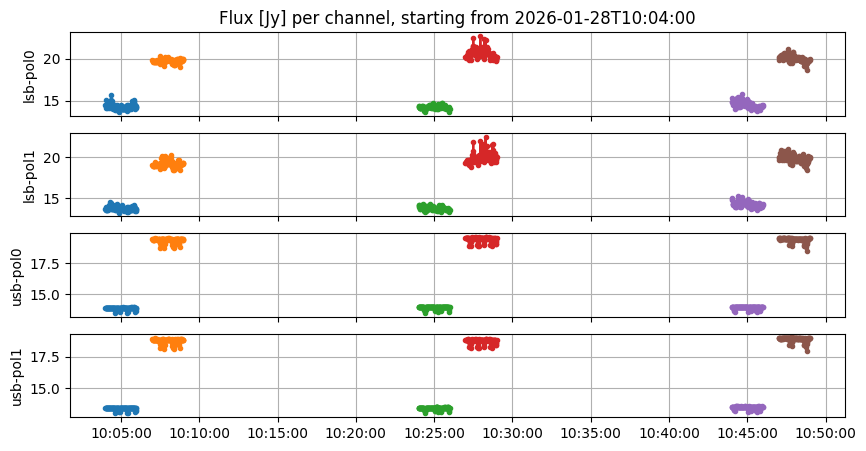

In [5]:
# Plot overview of created Tsys files

fig, axs = plt.subplots(4,1, figsize=(10,5), sharex=True)
plt_start_time = None
for scan_name, tsys_fn in tsys_fns.items():
    try:
        # Load CSV data with pandas
        df = pd.read_csv(tsys_fn)
        hdr_keys = df.keys().to_list()
        t_strlist = list(df['time'].array)
        t_axis = ap_time(t_strlist, format='isot') 
        if plt_start_time is None:
            plt_start_time = t_axis[0]
        for ii, key in enumerate(hdr_keys[1:]):
            axs[ii].plot(t_axis.to_datetime(), df[key].array, '.-')
    except Exception as e:
        print(e)
        pass
for ii in range(4):
    axs[ii].grid(), axs[ii].set_ylabel(hdr_keys[ii+1]), 
axs[-1].xaxis.set_major_formatter(DateFormatter('%H:%M:%S'))
axs[0].set_title('Flux [Jy] per channel, starting from '+str(plt_start_time).split('.')[0])

plt.show()

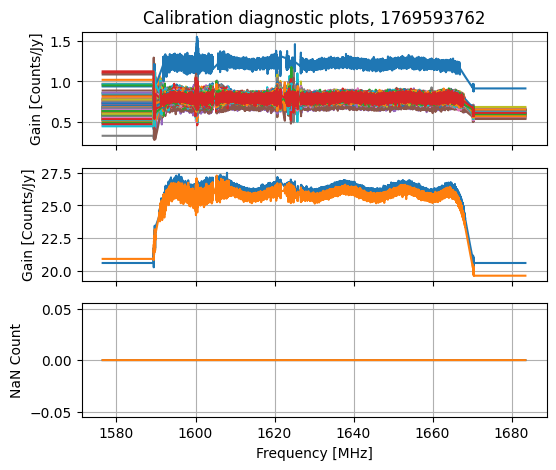

VLBI channel solutions, timestamp 1769594465.6092017:
- lsb-pol0: 26.24232510717282
- lsb-pol1: 25.89578281215167
- usb-pol0: 26.226409349146042
- usb-pol1: 25.86484218408051


In [6]:
# Plot calibration data diagnostic info

cal_sols.plot_sols()


In [7]:
# Print antab output for inspection

aw.print_all()


! Amplitude calibration data for ME in pcctest.
! Produced on 2026-01-30.
GAIN ME ELEV DPFU=1.0,1.0 FREQ=1578.49,1674.49 POLY=1.0 /
/
TSYS ME FT = 1.0 TIMEOFF=0
'R1','R2','L1','L2'
/
!Column 1 = R1: 1610.49 MHz, LSB, BW=32.0 MHz
!Column 2 = R2: 1642.49 MHz, USB, BW=32.0 MHz
!Column 3 = L1: 1610.49 MHz, LSB, BW=32.0 MHz
!Column 4 = L2: 1642.49 MHz, USB, BW=32.0 MHz
! 028 10:04.00: scanNum=0000 scanName=No0000 source=J1859-6615
028 10:04.00 14.4 13.9 13.6 13.5
028 10:04.02 14.4 13.9 13.6 13.5
028 10:04.03 14.2 13.9 13.5 13.5
028 10:04.05 14.4 13.9 13.6 13.5
028 10:04.07 15.0 13.9 13.9 13.5
028 10:04.08 14.3 13.9 13.6 13.5
028 10:04.10 14.2 13.9 13.6 13.5
028 10:04.12 14.2 13.9 13.6 13.5
028 10:04.13 14.3 13.9 13.6 13.5
028 10:04.15 14.3 13.9 13.6 13.5
028 10:04.17 14.3 13.9 13.7 13.5
028 10:04.18 14.4 13.9 13.8 13.5
028 10:04.20 14.3 13.9 13.7 13.5
028 10:04.22 14.4 13.9 14.0 13.5
028 10:04.23 14.2 13.9 13.7 13.5
028 10:04.25 14.8 13.9 14.1 13.5
028 10:04.27 14.7 13.9 14.1 13.5
028 10:04